**lag 추가 binary 삭제**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb

In [38]:
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/smart_factory/data/raw/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/smart_factory/data/raw/test.csv')

In [39]:
# ── timeslot 추가 ─────────────────────────────────────────
# 시나리오 내 슬롯 순서 (0~24)
# EDA에서 슬롯 0=11.3분 → 슬롯 24=21.9분으로 누적 증가 확인
train['timeslot'] = train.groupby('scenario_id').cumcount()
test['timeslot']  = test.groupby('scenario_id').cumcount()

In [40]:
drop_cols = ['ID', 'scenario_id', 'avg_delay_minutes_next_30m', 'layout_id']
target = 'avg_delay_minutes_next_30m'

In [41]:
# ── Lag 피처 ──────────────────────────────────────────────
train = train.sort_values(['scenario_id', 'timeslot']).reset_index(drop=True)
test  = test.sort_values(['scenario_id', 'timeslot']).reset_index(drop=True)

lag_cols = [
    'battery_mean',
    'low_battery_ratio',
    'order_inflow_15m',
    'robot_utilization',
    'robot_charging',
    'congestion_score',
]

for col in lag_cols:
    if col not in train.columns:
        continue
    # lag1: 직전 슬롯 값
    train[f'{col}_lag1'] = train.groupby('scenario_id')[col].shift(1)
    test[f'{col}_lag1']  = test.groupby('scenario_id')[col].shift(1)

    # diff1: 직전 슬롯 대비 변화량 (소모 속도)
    # battery_diff1이 음수 = 배터리 소모 중
    # order_diff1이 양수  = 주문 증가 중
    train[f'{col}_diff1'] = train[col] - train[f'{col}_lag1']
    test[f'{col}_diff1']  = test[col]  - test[f'{col}_lag1']

print(f'추가된 피처 수: {len(lag_cols) * 2}개')  # lag1 + diff1
print(f'전체 피처 수: {len(train.drop(columns=["ID","scenario_id",target,"layout_id"]).columns)}개')


추가된 피처 수: 12개
전체 피처 수: 103개


In [42]:
# ── 실험 5 추가 피처 ──────────────────────────────────────
# EDA 근거:
# 극고지연 그룹: order_inflow=145건(2.79배), robot_utilization=0.524(2.45배)
# 배터리는 56%로 정상 그룹(60%)과 거의 동일 → 극고지연 원인은 수요폭증×풀가동

# ① 수요-로봇 긴장도
# 주문이 많은데 로봇이 이미 풀가동 중인 상태
train['demand_robot_tension'] = (
    train['order_inflow_15m'].fillna(0) *
    train['robot_utilization'].fillna(0)
)
test['demand_robot_tension'] = (
    test['order_inflow_15m'].fillna(0) *
    test['robot_utilization'].fillna(0)
)

# ② 후반 고수요
# EDA: 극고지연 timeslot 중앙값=16, 슬롯 12 이후 발생 비율 급등
# 시나리오 후반(4시간+)에 주문이 많으면 누적 지연 폭발
train['late_high_demand'] = (
    (train['timeslot'] >= 12).astype(int) *
    train['order_inflow_15m'].fillna(0)
)
test['late_high_demand'] = (
    (test['timeslot'] >= 12).astype(int) *
    test['order_inflow_15m'].fillna(0)
)

# ③ 로봇 여유 없음 + 주문 압박
# robot_idle=0 (여유 로봇 없음) 상태에서 주문 유입
train['no_idle_order_pressure'] = (
    (train['robot_idle'] == 0).astype(int) *
    train['order_inflow_15m'].fillna(0)
)
test['no_idle_order_pressure'] = (
    (test['robot_idle'] == 0).astype(int) *
    test['order_inflow_15m'].fillna(0)
)

# ④ 충전 위기 중 주문 폭증
# 충전 중 로봇이 많은데 주문까지 많으면 이중 병목
train['charging_under_demand'] = (
    train['robot_charging'].fillna(0) *
    train['order_inflow_15m'].fillna(0)
)
test['charging_under_demand'] = (
    test['robot_charging'].fillna(0) *
    test['order_inflow_15m'].fillna(0)
)

print(f'추가 피처: demand_robot_tension, late_high_demand, '
      f'no_idle_order_pressure, charging_under_demand')

추가 피처: demand_robot_tension, late_high_demand, no_idle_order_pressure, charging_under_demand


In [43]:
X      = train.drop(columns=drop_cols).fillna(-999)
y      = train[target]
X_test = test.drop(columns=['ID', 'scenario_id', 'layout_id']).fillna(-999)
groups = train['scenario_id']

In [44]:
print(f'피처 수: {X.shape[1]}')
print(f'timeslot 포함 확인: {"timeslot" in X.columns}')
print(f'결측 수: {X.isnull().sum().sum()}')  # 0이어야 함


피처 수: 107
timeslot 포함 확인: True
결측 수: 0


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.263876 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23408
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 107
[LightGBM] [Info] Start training from score 9.016370
[200]	valid_0's l1: 9.58693
Fold 1 | MAE: 9.5843 | best iter: 255
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.275123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23404
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 107
[LightGBM] [Info] Start training from score 9.021746
Fold 2 | MAE: 9.3047 | best iter: 114
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.281117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23405
[LightGBM

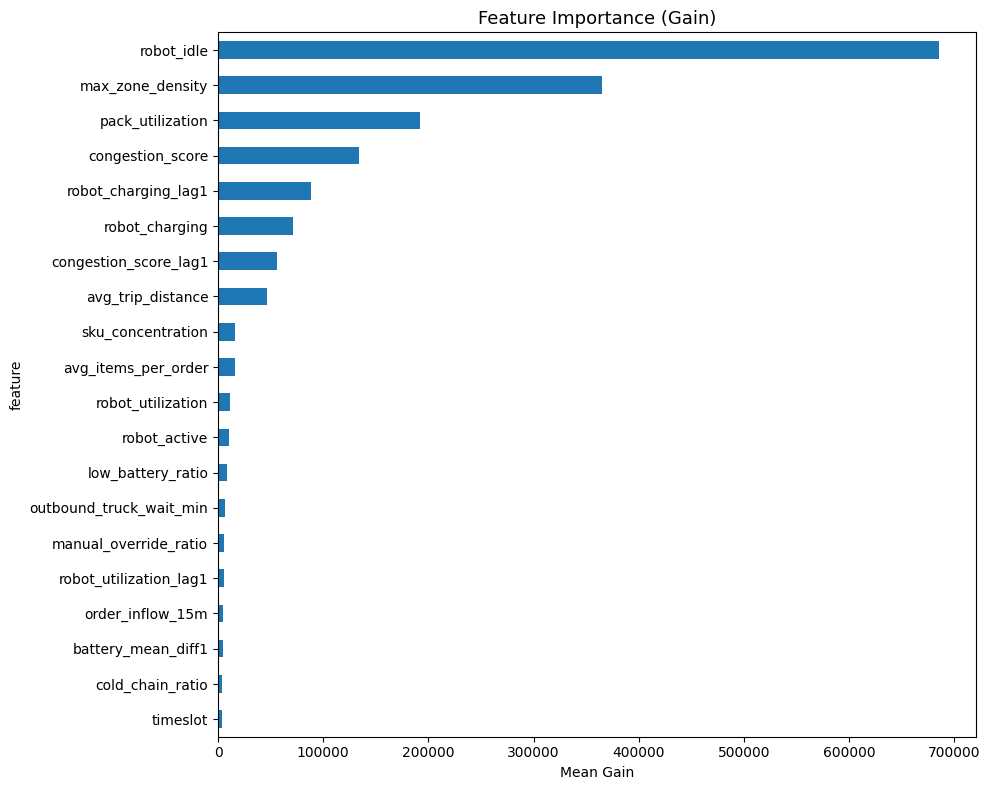

In [45]:
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt

# ── 5-Fold GroupKFold ─────────────────────────────────────
gkf = GroupKFold(n_splits=5)
oof_pred = np.zeros(len(X))
test_pred = np.zeros(len(X_test))
mae_scores = []
feature_importances = pd.DataFrame()

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(
        objective='mae',
        metric='mae',
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(200)
        ]
    )

    oof_pred[val_idx] = model.predict(X_val)
    test_pred += model.predict(X_test) / 5

    fold_mae = mean_absolute_error(y_val, oof_pred[val_idx])
    mae_scores.append(fold_mae)

    # gain 중요도로 기록
    imp = pd.DataFrame({
        'feature': X.columns,
        'gain': model.booster_.feature_importance(importance_type='gain'),
        'split': model.booster_.feature_importance(importance_type='split'),
        'fold': fold + 1
    })
    feature_importances = pd.concat([feature_importances, imp], axis=0)

    print(f'Fold {fold+1} | MAE: {fold_mae:.4f} | best iter: {model.best_iteration_}')

oof_mae = mean_absolute_error(y, oof_pred)
print(f'\n✅ 각 Fold MAE: {[round(m, 4) for m in mae_scores]}')
print(f'✅ 평균 MAE:    {np.mean(mae_scores):.4f}')
print(f'✅ OOF MAE:     {oof_mae:.4f}')

# ── 피처 중요도 (gain 기준) ───────────────────────────────
imp_mean = (
    feature_importances
    .groupby('feature')[['gain', 'split']]
    .mean()
    .sort_values('gain', ascending=False)
    .head(20)
)

print('\n✅ 상위 20개 피처 중요도 (gain 기준)')
print(imp_mean.round(1))

fig, ax = plt.subplots(figsize=(10, 8))
imp_mean['gain'].sort_values().plot.barh(ax=ax)
ax.set_title('Feature Importance (Gain)', fontsize=13)
ax.set_xlabel('Mean Gain')
plt.tight_layout()
plt.show()

# ── 제출용 예측값 후처리 ──────────────────────────────────
test_pred = np.clip(test_pred, 0, None)

In [47]:
#  추가한 피처 4개가 중요도
new_feats = ['demand_robot_tension', 'late_high_demand',
             'no_idle_order_pressure', 'charging_under_demand']

print('=== 새 피처 중요도 ===')
print(feature_importances.groupby('feature')['gain'].mean()
      .loc[new_feats].sort_values(ascending=False).round(1))

=== 새 피처 중요도 ===
feature
charging_under_demand     1122.7
demand_robot_tension       351.2
no_idle_order_pressure     178.8
late_high_demand           123.1
Name: gain, dtype: float64


In [48]:
test['prediction'] = test_pred

submission = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/smart_factory/sample_submission.csv')[['ID']]
submission = submission.merge(
    test[['ID', 'prediction']],
    on='ID',
    how='left'
)
submission = submission.rename(columns={'prediction': target})
submission.to_csv('baseline_v5_add_demand.csv', index=False)

print(f'예측값 범위: {submission[target].min():.2f} ~ {submission[target].max():.2f}')
print(f'NaN 수: {submission[target].isnull().sum()}')

예측값 범위: 0.47 ~ 41.10
NaN 수: 0
